In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [4]:
import pandas as pd
df=pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
#shape of the dataset
print("shape:",df.shape)

#Basic info
print("\n dtataset Info")
df.info()

# Statistical summary
print("\nStatistical summary")
df.describe()

shape: (768, 9)

 dtataset Info
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

Statistical summary


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [6]:
print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [7]:
# check duplicates
print("Duplicate rows:",df.duplicated().sum())

# Remove duplicates if any
df=df.drop_duplicates()
print("shape afetr removing duplicates:",df.shape)

Duplicate rows: 0
shape afetr removing duplicates: (768, 9)


In [8]:
# making the data dirty for practice

import numpy as np
import random

# save original clean data
df_clean=df.copy()

#add duplicate rows
df=pd.concat([df,df.iloc[0:5]],ignore_index=True)

# Add null values randomly

random.seed(42)

for col in ['Glucose','BMI','BloodPressure']:
    random_indices=random.sample(range(len(df)),10)
    df.loc[random_indices,col]=np.nan

#Add unrealistic zero values
df.loc[0:5,'insulin']=0
df.loc[6:10,'SkinThickness']=0

#Add outlier values
df.loc[1,'Glucose']=900
df.loc[2,'BMI']=150

print("Dirty dataset shape:",df.shape)
print("\nMissing values now")
print(df.isnull().sum())


Dirty dataset shape: (773, 10)

Missing values now
Pregnancies                   0
Glucose                      10
BloodPressure                10
SkinThickness                 0
Insulin                       0
BMI                          10
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
insulin                     767
dtype: int64


In [9]:
print(df.columns.tolist())

['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome', 'insulin']


In [10]:
df=df.drop(columns=['insulin'])

#verify
print("coloumns now:",df.columns.tolist())
print("shape now",df.shape)

coloumns now: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
shape now (773, 9)


In [11]:
# Cleaning the data

#check duplicates
df=df.drop_duplicates()
#verify
print('Duplicates after:',df.duplicated().sum())
print("shape after removing duplicates",df.shape)

Duplicates after: 0
shape after removing duplicates (770, 9)


In [12]:
#check missing values before
print("Missing values before:")
print(df.isnull().sum())

#Fill missing values with median of each column
df['Glucose'].fillna(df['Glucose'].mean(),inplace=True)
df['BloodPressure'].fillna(df['BloodPressure'].median(),inplace=True)
df['BMI'].fillna(df['BMI'].median(),inplace=True)

#check missing values after
print("\n missing values  after:")
print(df.isnull().sum())

Missing values before:
Pregnancies                  0
Glucose                     10
BloodPressure               10
SkinThickness                0
Insulin                      0
BMI                         10
DiabetesPedigreeFunction     0
Age                          0
Outcome                      0
dtype: int64

 missing values  after:
Pregnancies                  0
Glucose                     10
BloodPressure               10
SkinThickness                0
Insulin                      0
BMI                         10
DiabetesPedigreeFunction     0
Age                          0
Outcome                      0
dtype: int64


C:\Users\Shaikshavali\AppData\Local\Temp\ipykernel_17316\2187298897.py:6: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Glucose'].fillna(df['Glucose'].mean(),inplace=True)
C:\Users\Shaikshavali\AppData\Local\Temp\ipykernel_17316\2187298897.py:7: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series throu

In [13]:
#check missing values before
print("Missing values before:")
print(df.isnull().sum())

#Fill missing values with median of each column
df['Glucose']=df['Glucose'].fillna(df['Glucose'].mean())
df['BloodPressure']=df['BloodPressure'].fillna(df['BloodPressure'].median())
df['BMI']=df['BMI'].fillna(df['BMI'].median())

#check missing values after
print("\n missing values  after:")
print(df.isnull().sum())

Missing values before:
Pregnancies                  0
Glucose                     10
BloodPressure               10
SkinThickness                0
Insulin                      0
BMI                         10
DiabetesPedigreeFunction     0
Age                          0
Outcome                      0
dtype: int64

 missing values  after:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [14]:
# Check how many zeros exist in these columns
print("Zeros in Insulin:",(df['Insulin']==0).sum())
print("Zeros in SkinThickness:",(df['SkinThickness']==0).sum())

#Replace zeros with median
df['Insulin']=df['Insulin'].replace(0,df['Insulin'].median())
df['SkinThickness']=df['SkinThickness'].replace(0,df['SkinThickness'].median())

# Verify

print("\n Zeros in Insulin after:",(df['Insulin']==0).sum())
print("\nZeros in SkinThickness after:",(df['SkinThickness']==0).sum())

Zeros in Insulin: 376
Zeros in SkinThickness: 230

 Zeros in Insulin after: 0

Zeros in SkinThickness after: 0


In [15]:
# Check outliers before
print("Max Glucose:",df['Glucose'].max())
print("Max BMI:",df['BMI'].max())

# Remove rows where Glucose > 300 (impossible in real life)
df=df[df['Glucose']<300]

# Remove rows where BMI > 60 (impossible in real life)
df=df[df['BMI']<60]

# verify
print("Max Glucose:",df['Glucose'].max())
print("Max BMI:",df['BMI'].max())
print("shape after removing outliers:",df.shape)

Max Glucose: 900.0
Max BMI: 150.0
Max Glucose: 199.0
Max BMI: 59.4
shape after removing outliers: (767, 9)


In [16]:
from sklearn.preprocessing import StandardScaler

# Separate features (X) and target (Y)
# X = all columns except Outcome (these are inputs)
# Y = Outcome column only (this is what we want to predict)
X=df.drop(columns=['Outcome'])
y=df['Outcome']

# Create a StandardScaler object
# StandardScaler converts all values to same scale
# mean = 0 and standard deviation = 1
scaler=StandardScaler()

# fit_transform does two things:
# fit = learns the mean and std of each column
# transform = converts all values using that maen and std

X_scaled=scaler.fit_transform(X)

print("Scaling done!")
print("Shape of X:",X_scaled.shape)
print("shape of y:",y.shape)


Scaling done!
Shape of X: (767, 8)
shape of y: (767,)


In [17]:
from sklearn.model_selection import train_test_split

# split data into train and test
# test_size=0.2 means 20% data for testing,80% for the training
# random_state=42 means split will be same every time we run
X_train, X_test, y_train, y_test=train_test_split(X_scaled,y,test_size=0.2,random_state=42)

#check shapes

print("X_train shape:",X_train.shape)
print("X_test shape:",X_test.shape)
print("y_train shape:",y_train.shape)
print("y_test shape:",y_test.shape)

X_train shape: (613, 8)
X_test shape: (154, 8)
y_train shape: (613,)
y_test shape: (154,)


In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

#create Logistic Regression model
lr_model=LogisticRegression(random_state=42)

# train the model
# fit() = teaches the model using training data
lr_model.fit(X_train,y_train)

# predict on test data
# predict() = model predicts Outcome for unseen test data
lr_pred=lr_model.predict(X_test)

# Check accuracy
# accuracy_score = how many predictions were correct out of total
lr_accracy=accuracy_score(y_test,lr_pred)
print("LogisticRegression Accuracy :",lr_accracy)



LogisticRegression Accuracy : 0.7662337662337663


In [19]:
from sklearn.neighbors import KNeighborsClassifier

# create KNN model object
# n_neighbors=5 means look at 5 nearest neighbors
knn_model=KNeighborsClassifier(n_neighbors=5)

#Train the model
knn_model.fit(X_train,y_train)

#predict on test data
knn_pred=knn_model.predict(X_test)

# Check accuracy
knn_accuracy=accuracy_score(y_test,knn_pred)
print("KNN Accuracy:",knn_accuracy)

KNN Accuracy: 0.7792207792207793


In [20]:
from sklearn.tree import DecisionTreeClassifier

# create Decision tree model
# random_state=42 means same result every time
dt_model=DecisionTreeClassifier(random_state=42)

# Train the model
dt_model.fit(X_train,y_train)

# Predict on test data
dt_pred=dt_model.predict(X_test)

# Check accuracy
dt_accracy=accuracy_score(y_test,dt_pred)
print("Decision Tree Accuracy:",dt_accracy)



Decision Tree Accuracy: 0.6883116883116883


In [22]:
# Final comparision of all models

print("="*40)
print("       Model Comparision results")
print("="*40)
print(f"LogisticRegression    : {lr_accracy*100:.2f}%")
print(f"KNN                   : {knn_accuracy*100:.2f}%")
print(f"Decision tree         : {dt_accracy*100:.2f}%")
print("="*40)
print(f"Best model            : KNN with {knn_accuracy*100:.2f}% ")


       Model Comparision results
LogisticRegression    : 76.62%
KNN                   : 77.92%
Decision tree         : 68.83%
Best model            : KNN with 77.92% 


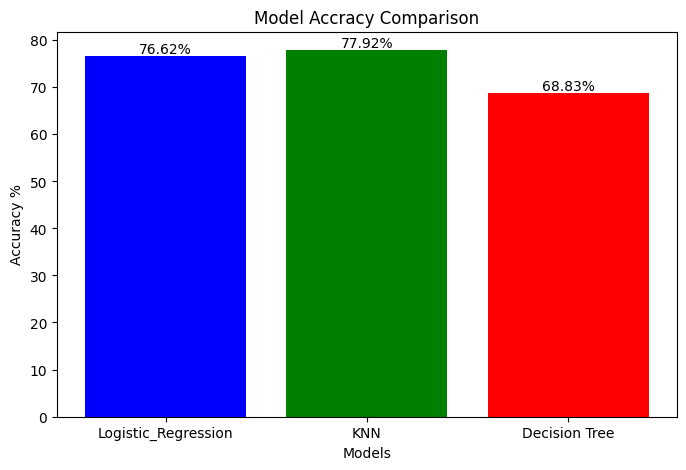

In [ ]:
# Data for graph
models=['Logistic_Regression','KNN','Decision Tree']
accuracies=[lr_accracy*100,knn_accuracy*100,dt_accracy*100]

# Create a bar chart
plt.figure(figsize=(8,5))

# bar() = creates bar chart
# models = X axis (model names)
# acctracies = y axis ( accuracy values)
# color = color of each bar
plt.bar(models,accuracies,color=['blue','green','red'])

# Add labels and title
plt.title('Model Accracy Comparison')
plt.xlabel('Models')
plt.ylabel('Accuracy %')

# Add accuracy value on top of each bar
for i,v in enumerate(accuracies):
    plt.text(i,v+0.5,f"{v:.2f}%",ha='center')

plt.show    


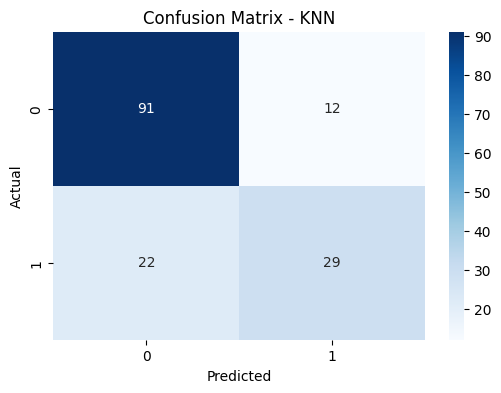

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# we will plot confusion matrix for best model (KNN)
cm= confusion_matrix(y_test,knn_pred)

# Create heatmap using seaborn
plt.figure(figsize=(6,4))

# heatmap() = creates a colored table
# annot=True = shows numbers inside the boxes
# fmt='d' = shows numbers as integers
# cmap='Blues' = color theme
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')

# Add labels and title
plt.title('Confusion Matrix - KNN')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [25]:
from sklearn.metrics import classification_report

# classification report for all 3 models
print("Logistic Regression Report:")
print(classification_report(y_test,lr_pred))

print("KNN  Report:")
print(classification_report(y_test,knn_pred))

print("Decision Tree  Report:")
print(classification_report(y_test,dt_pred))

Logistic Regression Report:
              precision    recall  f1-score   support

           0       0.82      0.83      0.83       103
           1       0.65      0.63      0.64        51

    accuracy                           0.77       154
   macro avg       0.74      0.73      0.73       154
weighted avg       0.76      0.77      0.77       154

KNN  Report:
              precision    recall  f1-score   support

           0       0.81      0.88      0.84       103
           1       0.71      0.57      0.63        51

    accuracy                           0.78       154
   macro avg       0.76      0.73      0.74       154
weighted avg       0.77      0.78      0.77       154

Decision Tree  Report:
              precision    recall  f1-score   support

           0       0.77      0.77      0.77       103
           1       0.53      0.53      0.53        51

    accuracy                           0.69       154
   macro avg       0.65      0.65      0.65       154
weighted a

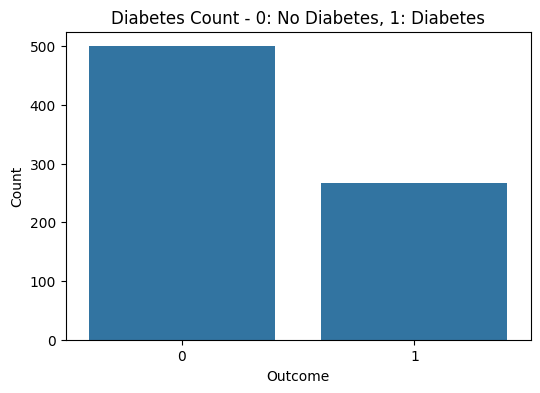

In [26]:
# Graph 1 - count plot
plt.figure(figsize=(6,4))

# countplot() = counts and plots each category
# x= 'Outcome' = column to count
# data=df = dataset to use
sns.countplot(x='Outcome',data=df)

# Add labels
plt.title('Diabetes Count - 0: No Diabetes, 1: Diabetes')
plt.xlabel('Outcome')
plt.ylabel('Count')

plt.show()

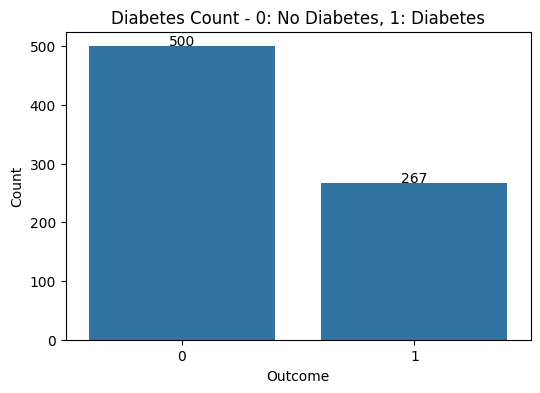

In [27]:
# Graph 1 - count plot
plt.figure(figsize=(6,4))

# countplot() = counts and plots each category
# x= 'Outcome' = column to count
# data=df = dataset to use
ax=sns.countplot(x='Outcome',data=df)

# Add numbers on top of each bar
for p in ax.patches:
    ax.annotate(int(p.get_height()),(p.get_x()+p.get_width()/2,p.get_height()+1),ha='center')
# Add labels
plt.title('Diabetes Count - 0: No Diabetes, 1: Diabetes')
plt.xlabel('Outcome')
plt.ylabel('Count')

plt.show()

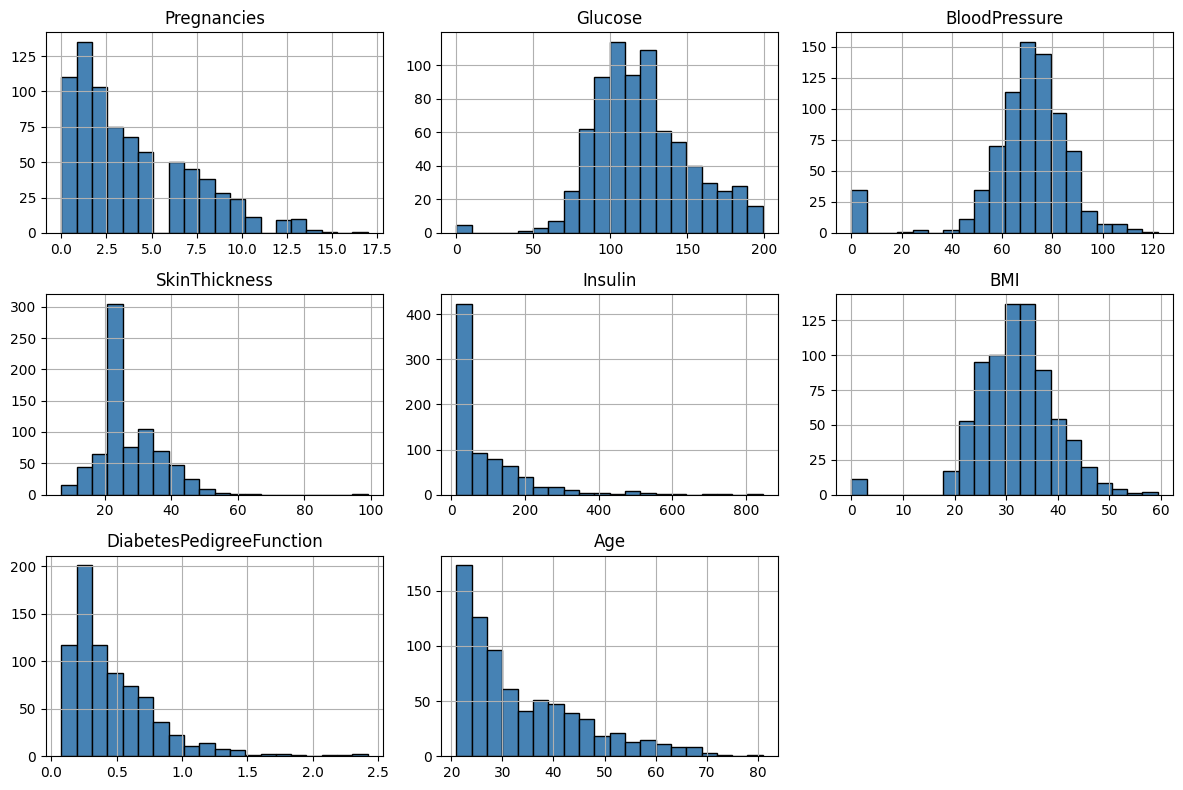

In [28]:
# graph 2 - Histogram for all features
plt.figure(figsize=(12,8))

#Loop through all columns except Outcome
for i, col in enumerate(df.columns[:-1]):
    plt.subplot(3,3,i+1) # creates 3X3 grid of graphs

    # hist() = creates histogram
    # bins=20 = divides data into 20 groups
    # color = bar color
    df[col].hist(bins=20,color='steelblue',edgecolor='black')

    plt.title(col) # column name as title

plt.tight_layout()  # adjust spacing between graphs
plt.show()   


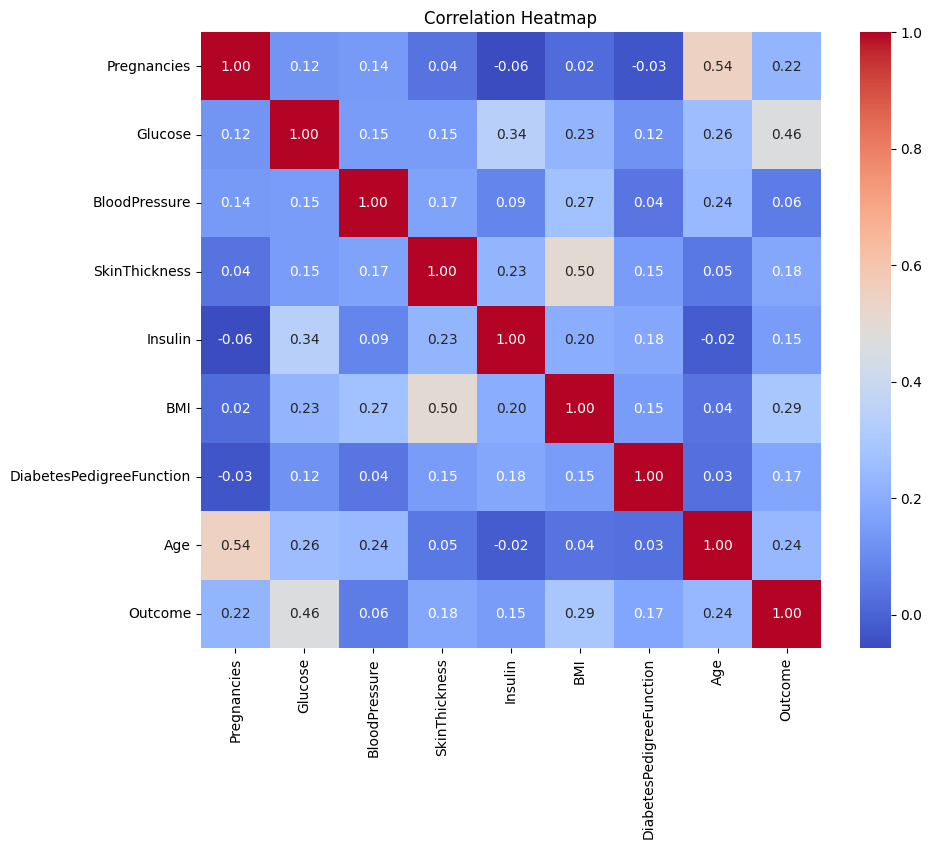

In [ ]:
# Graph 3 - Correlation Heatmap
plt.figure(figsize=(10,8))

# corr() = calculates correlation between all columns
correlation=df.corr()

# heatmap() = shows correlation as colored tabled
# annot = True = shows numbers inside the boxes
# cmap ='coolwarm' = color theme (blue=negative,red=positive)
# fmt='.2f' = shows 2 decimal places

sns.heatmap(correlation,annot=True,cmap='coolwarm',fmt='.2f')

plt.title('Correlation Heatmap')
plt.show()

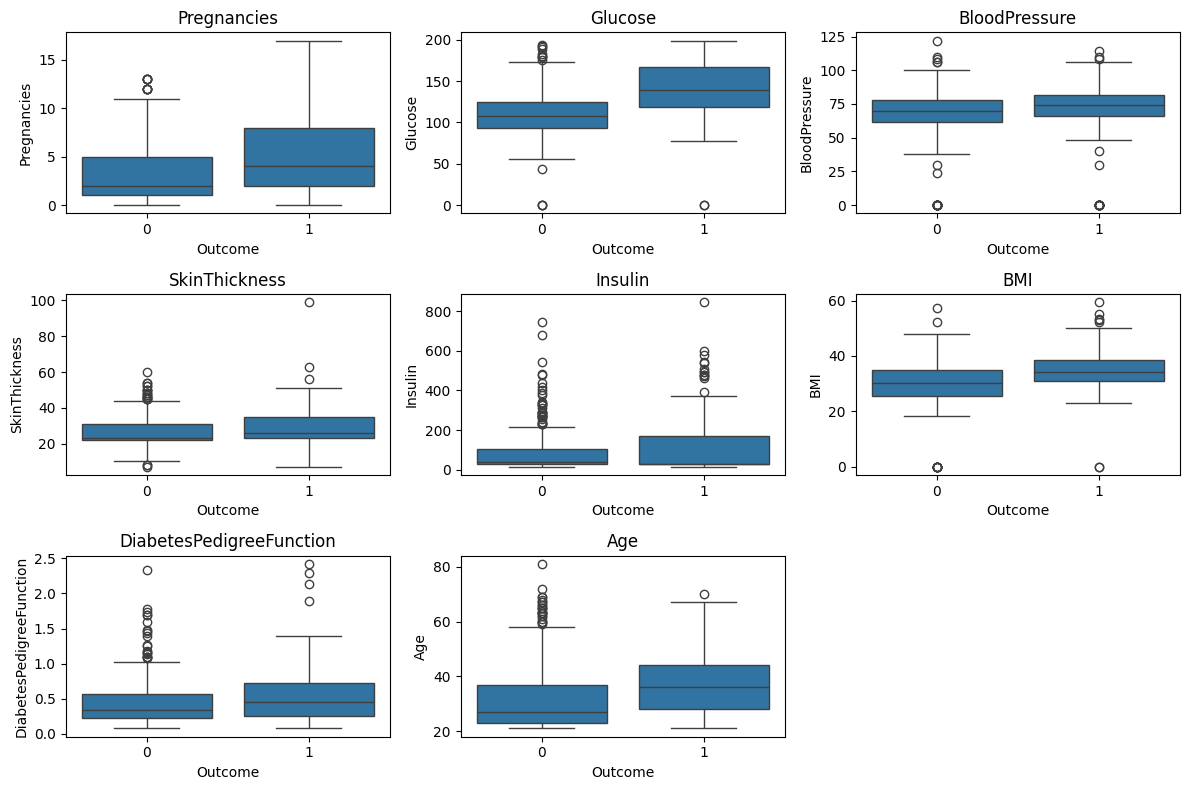

In [30]:
# Graph 4 - Box Plot
plt.figure(figsize=(12,8))

# Loop through all columns except Outcome
for i,col in enumerate(df.columns[:-1]):
    plt.subplot(3,3,i+1)

    # boxplot() = creates box plot
    # x='Outcome' = group by diabetic/non diabetic
    # y=col = feature to compare
    # data=df = dataset
    sns.boxplot(x='Outcome',y=col,data=df)

    plt.title(col)

plt.tight_layout()
plt.show()    

In [32]:
print(df.shape)
print(df.head())

(767, 9)
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6    148.0           72.0             35       27  33.6   
3            1     89.0           66.0             23       94  28.1   
4            0    137.0           40.0             35      168  43.1   
5            5    116.0           74.0             23       27  25.6   
6            3     78.0           50.0             23       88  31.0   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
3                     0.167   21        0  
4                     2.288   33        1  
5                     0.201   30        0  
6                     0.248   26        1  
